Name: Anuj Prasad Pradhan
ID: 2408570

# Part 3 – Sentiment Classification with RNN/LSTM

This notebook builds and evaluates three sequence models (Simple RNN, Bidirectional LSTM, and word2vec LSTM) for sentiment classification on hotel reviews. The pipeline covers text preprocessing, tokenisation, padding, model training, evaluation, error analysis, and a live Gradio demo.

**Dataset:** Hotel Reviews CSV (Google Drive)


## 1. Setup

### 1.1 Install Dependencies & Mount Drive


In [121]:
!pip install contractions

### 1.2 Imports

In [86]:
# standard library and third-party imports used throughout the notebook
# includes sklearn metrics, numpy/pandas, NLP tools, keras layers, and seaborn
import time
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers


In [8]:
# mount Google Drive so the dataset CSV is accessible in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# path to the hotel reviews dataset on the shared drive
text_dir = "/content/drive/Shareddrives/AI/2. Hotel Review Dataset/Hotel_Reviews.csv"

## 2. Load the Dataset

Load the CSV file with Pandas using `ISO-8859-1` encoding (required for the hotel-review data). We inspect the shape and a preview of the first few rows.

In [122]:
# read the CSV with latin-1 encoding to handle special characters


data = pd.read_csv(text_dir, encoding="ISO-8859-1")
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 2.1 Explore Rating Distribution

Check how many reviews fall into each star rating (1–5) to understand class balance before preprocessing.

In [123]:
# Count how many rows for each rating
print(data['Rating'].value_counts())

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


### 2.2 Check for Missing Values

Identify null values across the dataset so we can decide whether to drop or impute them.

In [124]:
data.isna()


,Review,Rating
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
20486,False,False
20487,False,False
20488,False,False
20489,False,False


In [125]:
data.isnull()

,Review,Rating
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
20486,False,False
20487,False,False
20488,False,False
20489,False,False


In [126]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


### 2.3 Keep Relevant Columns & Drop NaN Rows

Retain only the `Review` (text) and `Rating` (label) columns, then drop rows with missing values.

In [127]:
data = data[['Review', 'Rating']]  # keep only needed columns
data.dropna(inplace=True)
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## 3. Text Cleaning & Preprocessing



In [128]:
# download required NLTK data and initialise stopwords and lemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 3.1 `clean_text()` – Regex-Based Cleaning

Applies regex patterns sequentially to normalise raw text.

In [129]:
def clean_text(text):
    # lowercase
    text = text.lower()

    # expand contractions (VERY IMPORTANT)
    text = contractions.fix(text)

    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### 3.2 `preprocess_text()` – Tokenisation, Stopword Removal & Lemmatisation

Builds on `clean_text()` to tokenise, filter stopwords, and lemmatise.

In [130]:
def preprocess_text(text):
    text = clean_text(text)

    tokens = text.split()

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

### 3.3 Apply the Preprocessing Pipeline

Run `preprocess_text()` on every review. This may take a few minutes depending on dataset size.

In [131]:
print("Cleaning text...")

data['cleaned_review'] = data['Review'].apply(preprocess_text)

data.head()

Cleaning text...


,Review,Rating,cleaned_review
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...


## 4. Visualise the Cleaned Data

Explore the cleaned vocabulary with a **Word Cloud** (most frequent words visually) and a **Top-20 word frequency list** to confirm noise removal.

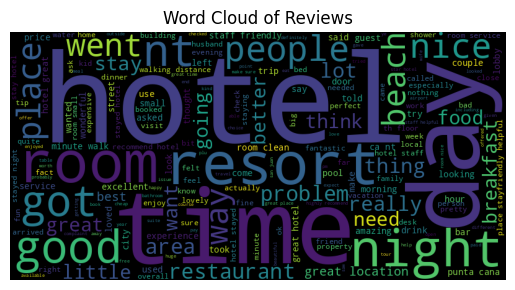

In [132]:
# join all cleaned reviews into one string and generate a word cloud


text = " ".join(data['cleaned_review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Reviews")
plt.show()

### 4.1 Top 20 Most Frequent Words

In [133]:
# count word frequencies and print the 20 most common tokens

all_words = text.split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('hotel', 52957), ('room', 46378), ('great', 21098), ('nt', 19007), ('good', 17055), ('staff', 16280), ('stay', 15341), ('night', 14084), ('day', 12963), ('time', 12612), ('nice', 12412), ('location', 11236), ('service', 10538), ('stayed', 10469), ('restaurant', 10092), ('beach', 10047), ('breakfast', 9655), ('place', 9381), ('clean', 9373), ('food', 9259)]


## 5. Label Encoding & Train / Test Split (80 / 20)

Convert the 1–5 star ratings to three sentiment classes:
- **0 – Negative** (rating ≤ 2)
- **1 – Neutral** (rating = 3)
- **2 – Positive** (rating ≥ 4)

Split the dataset 80 % training / 20 % testing with `random_state=42` for reproducibility.

In [134]:


def convert_rating(r):
    if r <= 2:
        return 0   # Negative
    elif r == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

data['sentiment'] = data['Rating'].apply(convert_rating)

X = data['cleaned_review']
y = data['sentiment']
num_classes = 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 16392
Test size: 4099


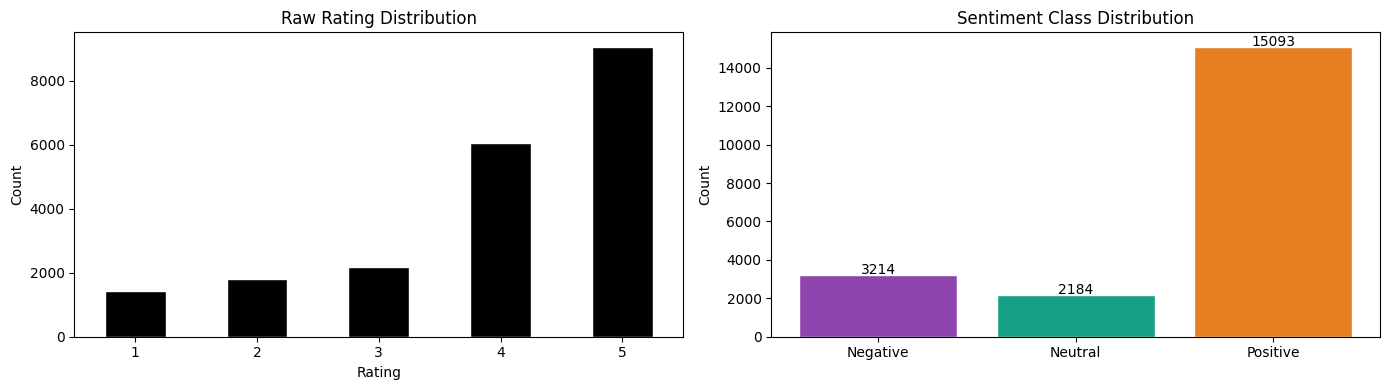

Class counts: {'Negative': np.int64(3214), 'Neutral': np.int64(2184), 'Positive': np.int64(15093)}


In [176]:
counts = data['sentiment'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw rating distribution
data['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='black', edgecolor='white')
axes[0].set_title('Raw Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

# Sentiment class distribution
axes[1].bar(CLASS_NAMES, counts.values,
            color=['#8E44AD','#16A085','#E67E22'], edgecolor='white')
axes[1].set_title('Sentiment Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print('Class counts:', dict(zip(CLASS_NAMES, counts.values)))

## 6. Keras Tokenisation

Use `Tokenizer` to build a vocabulary of the top `vocab_size=5000` words and convert each review into integer index sequences. The `<OOV>` token handles words not seen during training.

In [135]:
# build vocabulary from training set and convert text to integer sequences
# vocab capped at 5000 most frequent words; OOV token used for unknown words


vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

## 7. Percentile-Based Sequence Padding

Rather than padding to the maximum length (which could be very long due to outliers), we use the **90th percentile** of training sequence lengths as `max_len`. Sequences shorter than `max_len` are zero-padded at the end (`padding='post'`); longer ones are truncated.

In [136]:
# compute 90th percentile length to avoid over-padding due to outlier long reviews
# pad/truncate all sequences to this fixed length


lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(lengths, 90))  # VERY IMPORTANT

print("Max sequence length:", max_len)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

Max sequence length: 189


### 7.1 Verify Padded Shapes

In [137]:
print("Shape of padded train data:", X_train_pad.shape)
print("Shape of padded test data:", X_test_pad.shape)

Shape of padded train data: (16392, 189)
Shape of padded test data: (4099, 189)


## 8. Handle Class Imbalance with Class Weights

Hotel reviews are heavily skewed toward positive ratings. `compute_class_weight('balanced', ...)` assigns higher loss weight to minority classes (Negative and Neutral) so the model does not simply predict Positive for every input.

In [138]:
# compute balanced class weights to counteract the skew toward positive reviews
# convert to dict format required by keras fit()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights", class_weights)

Class weights {0: np.float64(2.1104673619157976), 1: np.float64(3.1187214611872145), 2: np.float64(0.4534063563189777)}


### 8.1 Shared Hyperparameter

Set the embedding dimension used by Model 1 (Simple RNN).

In [139]:
# embedding dimension for the trainable embedding layer in Model 1


embedding_dim = 100

## 9. Model 1 – Simple RNN

A lightweight baseline model:
- `Embedding(vocab_size, embedding_dim)` – trainable lookup table mapping word indices to dense vectors.
- `SimpleRNN(64)` – recurrent layer processing tokens sequentially.
- `Dense(32, relu)` → `Dense(3, softmax)` – classification head.

Simple RNNs are fast but can suffer from the **vanishing gradient** problem on longer sequences.

### 9.1 Define Model

In [146]:
# sequential model: embedding -> simple RNN -> dense layers -> softmax output
model_rnn = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    ),

    SimpleRNN(64),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 9.2 Compile Model

- **Loss**: `sparse_categorical_crossentropy` (integer class labels, multi-class output).
- **Optimiser**: `adam` (adaptive learning rate).
- **Metric**: `accuracy`.

In [147]:
# compile with categorical crossentropy loss and adam optimizer
model_rnn.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

### 9.3 Train Model

Training uses **EarlyStopping** (`patience=5`, monitoring `val_loss`) to halt when validation loss stops improving. Class weights counter class imbalance.

In [148]:
# early stopping halts training if val_loss does not improve for 3 epochs
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [149]:
# flatten labels to 1D arrays as required by sparse_categorical_crossentropy
# train the RNN and record wall-clock training time
y_train_flat = y_train.values.flatten()
y_test_flat = y_test.values.flatten()

rnn_start_time = time.time()
history_rnn = model_rnn.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)
rnn_end_time = time.time()
print(f"Training Time: {rnn_end_time - rnn_start_time} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.2523 - loss: 1.1061 - val_accuracy: 0.2315 - val_loss: 1.1189 - learning_rate: 0.0010
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2966 - loss: 1.1135 - val_accuracy: 0.3205 - val_loss: 1.1153 - learning_rate: 0.0010
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3532 - loss: 1.1091 - val_accuracy: 0.2775 - val_loss: 1.1047 - learning_rate: 0.0010
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4438 - loss: 1.0994 - val_accuracy: 0.4928 - val_loss: 1.1221 - learning_rate: 0.0010
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4577 - loss: 1.0919 - val_accuracy: 0.5349 - val_loss: 1.1184 - learning_rate: 0.0010
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4975 - loss: 1.0880 - val_accuracy: 0.5361 - val_loss: 1.0594 - learning_rate: 5.0000e-04
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5064 - los

### 9.4 Training Curves

Plot training vs validation accuracy and loss to detect overfitting.

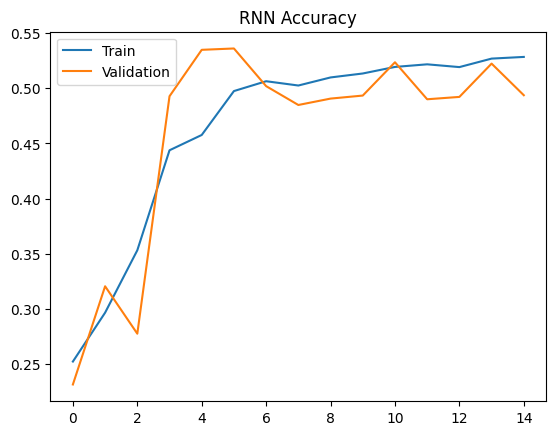

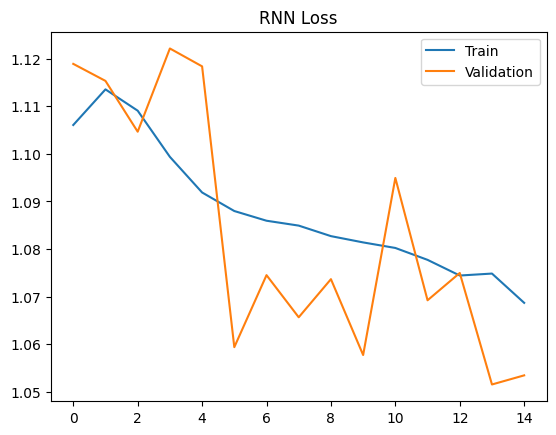

In [150]:
# helper: plot accuracy and loss curves for train vs validation
# called immediately with the RNN history
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['Train', 'Validation'])
    plt.show()
plot_history(history_rnn, "RNN")

### 9.5 Evaluate Model 1 – Simple RNN

Generate a classification report and confusion matrix on the held-out test set.

In [151]:
# helper: run inference, print classification report and confusion matrix
# called immediately with the trained RNN model
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print(f"\n{name} Results:\n")
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred_classes))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred_classes))
evaluate_model(model_rnn, X_test_pad, y_test, "RNN")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

RNN Results:

Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.58      0.30       625
           1       0.12      0.03      0.05       432
           2       0.81      0.59      0.68      3042

    accuracy                           0.53      4099
   macro avg       0.38      0.40      0.35      4099
weighted avg       0.65      0.53      0.56      4099

Confusion Matrix:

[[ 360   28  237]
 [ 243   15  174]
 [1165   87 1790]]


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


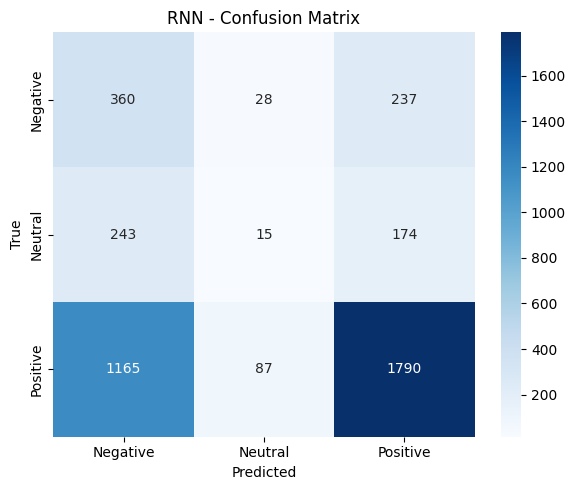

In [152]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, X_test, y_test, class_names, name="Model"):
    # Predict classes
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_classes)

    # Plot heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
class_labels = ["Negative", "Neutral", "Positive"]
plot_confusion_matrix(model_rnn, X_test_pad, y_test, class_labels, name="RNN")



## 10. Model 2 – Bidirectional LSTM

An improved architecture that addresses vanishing gradients and reads sequences in both directions:
- `Embedding(vocab_size, 128)` – trainable embeddings with higher dimensionality.
- `Bidirectional(LSTM(64, return_sequences=True))` – captures context from past **and** future tokens.
- `Dropout(0.3)` – regularisation to reduce overfitting.
- `LSTM(64)` – second recurrent layer.
- `Dense(64, relu)` → `Dropout(0.3)` → `Dense(3, softmax)`.

### 10.1 Define Model

In [153]:
# bidirectional LSTM reads sequences forwards and backwards for richer context
model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 10.2 Compile Model

In [154]:
# same compile settings as Model 1
model_lstm.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

### 10.3 Train Model

In [155]:
# reset early stopping callback for this model's training run

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [156]:
# flatten labels and train the Bidirectional LSTM, recording training time

lstm_start_time = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)
lstm_end_time = time.time()
print(f"Training Time: {lstm_end_time - lstm_start_time} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.3541 - loss: 1.1008 - val_accuracy: 0.1202 - val_loss: 1.1026 - learning_rate: 0.0010
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4221 - loss: 1.0930 - val_accuracy: 0.1415 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3693 - loss: 1.0598 - val_accuracy: 0.1421 - val_loss: 1.1025 - learning_rate: 0.0010
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.4901 - loss: 1.0178 - val_accuracy: 0.2177 - val_loss: 1.1325 - learning_rate: 5.0000e-04
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.5530 - loss: 0.9548 - val_accuracy: 0.7542 - val_loss: 0.9102 - learning_rate: 5.0000e-04
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.7773 - loss: 0.7684 - val_accuracy: 0.7426 - val_loss: 0.7314 - learning_rate: 5.0000e-04
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy

### 10.4 Training Curves

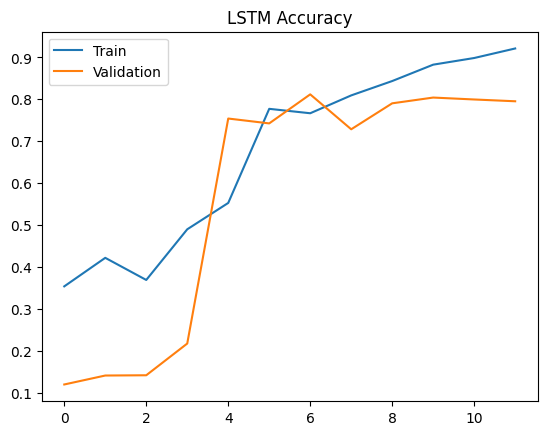

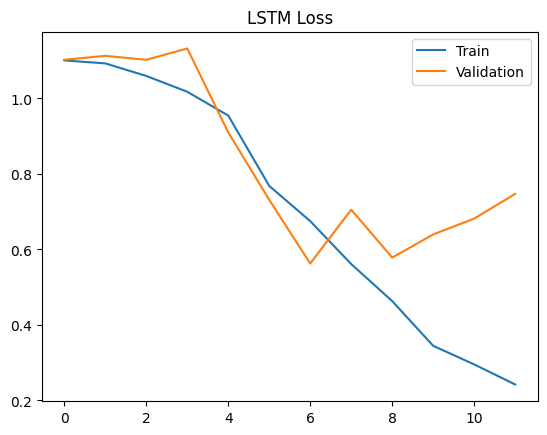

In [157]:
# plot accuracy and loss curves then call with LSTM history
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['Train', 'Validation'])
    plt.show()
plot_history(history_lstm, "LSTM")

### 10.5 Evaluate Model 2 – Bidirectional LSTM

In [158]:
# print classification report and confusion matrix for the LSTM model
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print(f"\n{name} Results:\n")
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred_classes))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred_classes))
evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

LSTM Results:

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.64      0.66       625
           1       0.28      0.34      0.31       432
           2       0.91      0.90      0.90      3042

    accuracy                           0.80      4099
   macro avg       0.63      0.62      0.62      4099
weighted avg       0.81      0.80      0.80      4099

Confusion Matrix:

[[ 398  138   89]
 [ 103  147  182]
 [  72  241 2729]]


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


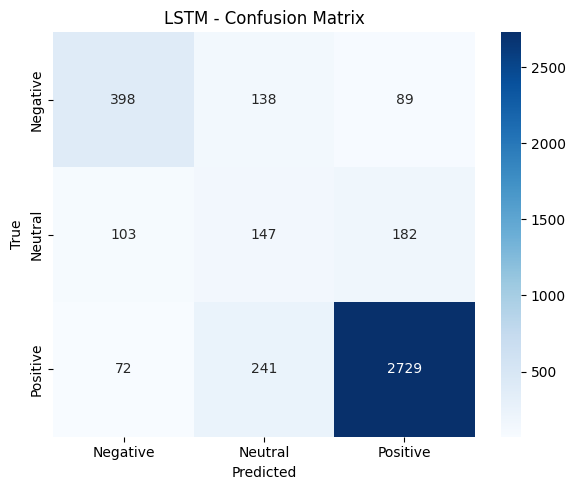

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, X_test, y_test, class_names, name="Model"):
    # Predict classes
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_classes)

    # Plot heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
class_labels = ["Negative", "Neutral", "Positive"]
plot_confusion_matrix(model_lstm, X_test_pad, y_test, class_labels, name="LSTM")


## 11. Model 3 – LSTM with Pretrained word2vec Embeddings

Uses **word2vec (word2vec-google-news-300)** pretrained word vectors via `gensim.downloader`. The embedding layer is **frozen** (`trainable=False`) so pretrained representations are preserved.

Pretrained embeddings capture rich semantic relationships (e.g. *king – man + woman ≈ queen*) that a small trainable layer cannot learn from the training set alone.

### 11.1 Install Gensim

In [160]:
!pip install numpy==1.23.5
!pip install gensim

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### 11.2 Load Pretrained Word2Vec Vectors

In [161]:
# download and load 100-dimensional word2vec vectors trained on Wikipedia + Gigaword
import gensim.downloader as api

w2v_model = api.load("word2vec-google-news-300")
embedding_dim_w2v = 300

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### 11.3 Build the Embedding Matrix

Map every word in the Keras tokeniser's vocabulary to its 100-dim Word2Vec vector. Words not found in word2vec remain as zero vectors.

In [162]:
# initialise a zero matrix of shape (vocab_size, 100)
# fill rows where the word exists in the pretrained Word2Vec model

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model:
            embedding_matrix[i] = w2v_model[word]

### 11.4 Define Model

In [163]:
# trainable=False freezes the embedding layer to preserve pretrained knowledge
model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False   # important
    ),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 11.5 Compile Model

In [164]:
# same compile settings as Models 1 and 2
model_w2v.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

### 11.6 Train Model

In [165]:
# reset early stopping for word2vec LSTM training run

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [166]:
# train the W2V LSTM and record training time
y_train_flat = y_train.values.flatten()
y_test_flat = y_test.values.flatten()

w2v_start_time = time.time()
history_w2v = model_w2v.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)
w2v_end_time = time.time()
print(f"Training Time: {w2v_end_time - w2v_start_time} seconds")

Epoch 1/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.4527 - loss: 1.0984 - val_accuracy: 0.7206 - val_loss: 1.0936 - learning_rate: 0.0010
Epoch 2/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4762 - loss: 1.0964 - val_accuracy: 0.6880 - val_loss: 1.0946 - learning_rate: 0.0010
Epoch 3/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6539 - loss: 1.0917 - val_accuracy: 0.1583 - val_loss: 1.1152 - learning_rate: 0.0010
Epoch 4/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6354 - loss: 1.0773 - val_accuracy: 0.7017 - val_loss: 1.1009 - learning_rate: 5.0000e-04
Epoch 5/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5993 - loss: 1.0623 - val_accuracy: 0.6944 - val_loss: 1.0902 - learning_rate: 5.0000e-04
Epoch 6/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4019 - loss: 1.0834 - val_accuracy: 0.6932 - val_loss: 1.0904 - learning_rate: 5.0000e-04
Epoch 7/15
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.554

### 11.7 Training Curves

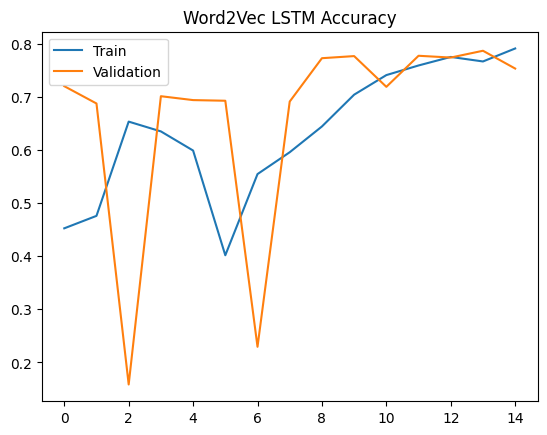

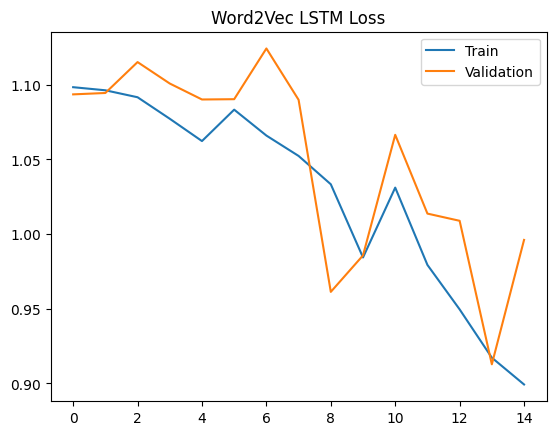

In [167]:
# plot training curves for the word2vec LSTM model

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['Train', 'Validation'])
    plt.show()
plot_history(history_w2v, "Word2Vec LSTM")

### 11.8 Evaluate Model 3 – LSTM + Word2Vec

In [168]:
# print classification report and confusion matrix for the word2vec LSTM
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print(f"\n{name} Results:\n")
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred_classes))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred_classes))
evaluate_model(model_w2v, X_test_pad, y_test, "Word2Vec LSTM")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Word2Vec LSTM Results:

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.57      0.61       625
           1       0.17      0.06      0.09       432
           2       0.83      0.93      0.88      3042

    accuracy                           0.78      4099
   macro avg       0.55      0.52      0.52      4099
weighted avg       0.73      0.78      0.75      4099

Confusion Matrix:

[[ 354   38  233]
 [  66   25  341]
 [ 123   82 2837]]


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


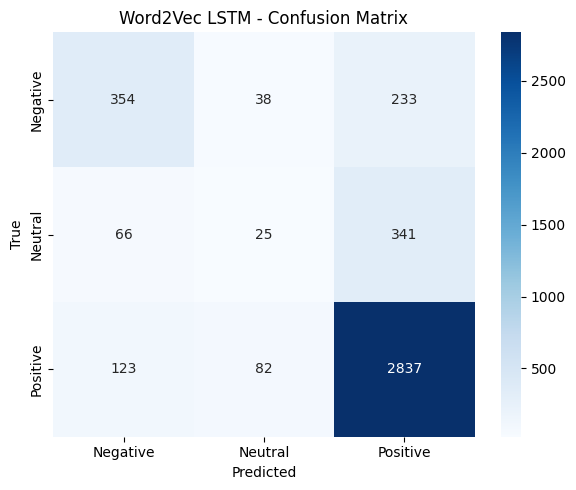

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, X_test, y_test, class_names, name="Model"):
    # Predict classes
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_classes)

    # Plot heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
class_labels = ["Negative", "Neutral", "Positive"]
plot_confusion_matrix(model_w2v, X_test_pad, y_test, class_labels, name="Word2Vec LSTM")


## 12. Model Comparison – Test Accuracy Bar Chart

Visualise the final test accuracy of all three models side-by-side to identify the best-performing architecture.

/tmp/ipykernel_9307/934837046.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Test Accuracy', data=model_test_accuracies, palette='viridis')


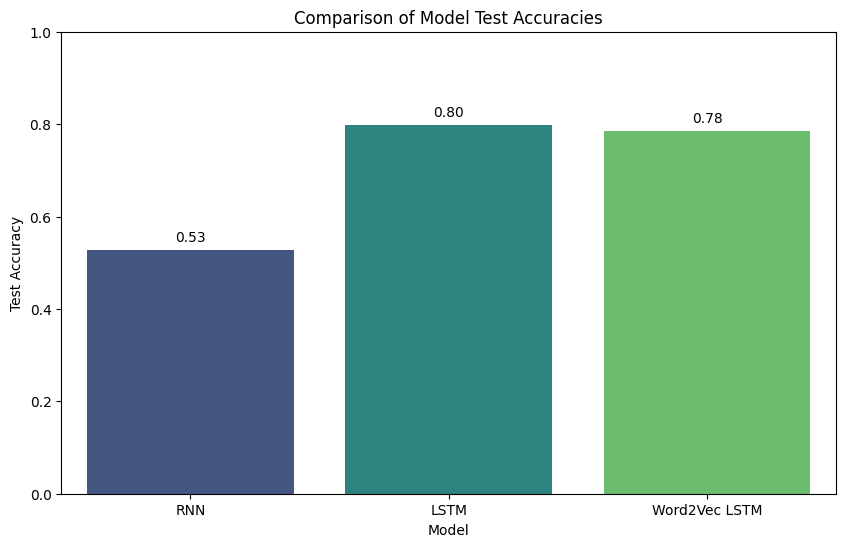

In [170]:
# Evaluate each model on the test data to get the test accuracy
rnn_test_loss, rnn_test_accuracy = model_rnn.evaluate(X_test_pad, y_test_flat, verbose=0)
lstm_test_loss, lstm_test_accuracy = model_lstm.evaluate(X_test_pad, y_test_flat, verbose=0)
w2v_lstm_test_loss, w2v_lstm_test_accuracy = model_w2v.evaluate(X_test_pad, y_test_flat, verbose=0)

# Create a DataFrame for easy plotting
model_test_accuracies = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'Word2Vec LSTM'],
    'Test Accuracy': [rnn_test_accuracy, lstm_test_accuracy, w2v_lstm_test_accuracy]
})

# Plotting the bar graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Test Accuracy', data=model_test_accuracies, palette='viridis')
plt.title('Comparison of Model Test Accuracies')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

## 13. Error Analysis

### 13.1 Misclassified Examples

Inspect 2–3 incorrect predictions made by the best model (Bidirectional LSTM) to understand where the model struggles.

In [171]:
# find indices where predictions differ from ground truth
# print the original text, actual label, and predicted label for the first n errors
def show_errors(model, X_test, y_test, texts, n=3):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    errors = np.where(y_pred_classes != y_test)[0]

    for i in errors[:n]:
        print("TEXT:", texts.iloc[i])
        print("Actual:", y_test.iloc[i])
        print("Predicted:", y_pred_classes[i])
        print("-"*50)

In [172]:
# run error analysis using the Bidirectional LSTM model
show_errors(model_lstm, X_test_pad, y_test, X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
TEXT: ok hotel good location stayed night way beijing rawa island hotel service room ok location great shopping restaurant probably stay opinion nice star hotel
Actual: 1
Predicted: 0
--------------------------------------------------
TEXT: great service nice pool ok beach lovely ground small room stayed day night st th quick cab ride hotel line checkin requested king bed guaranteed offered double b club level floor thrilled went ground hotel beautiful issue poster close airport nonissue inside hotel heard plane taking outside hotel heard thrust engine twice white noise wind pool people ocean airport thought club level nice compare club level st regis aspen pale compared worth upgrade club level sitting day food drink champagnewinemixed drink night free newspaper coffee drink nice touch young family especially baby club level opinion open pm service club level great staffed personal concierge food club level ok impression mass production conven

## 14. GUI for Real-Time Prediction

A simple interactive interface built with **Gradio** lets a user type a hotel review and receive an instant sentiment prediction from the best-trained model (Bidirectional LSTM).


In [ ]:
# install gradio for building the interactive prediction UI
!pip install gradio --quiet


In [173]:
# define the prediction function: preprocess -> tokenise -> pad -> predict
# build and launch the Gradio interface with example reviews
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

def predict_sentiment(review_text):
    """Preprocess the input text and return a sentiment prediction."""
    if not review_text.strip():
        return "Please enter a review.", {}

    # Apply the same preprocessing pipeline used during training
    cleaned = preprocess_text(review_text)

    # Tokenise and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # Predict with the Bidirectional LSTM (Model 2)
    probs = model_lstm.predict(padded, verbose=0)[0]
    pred_class = int(np.argmax(probs))

    confidence = {label_map[i]: float(round(probs[i], 4)) for i in range(3)}
    return label_map[pred_class], confidence


# Build the Gradio interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type a hotel review here...",
        label="Hotel Review"
    ),
    outputs=[
        gr.Text(label="Predicted Sentiment"),
        gr.Label(label="Confidence Scores", num_top_classes=3)
    ],
    title="Hotel Review Sentiment Classifier",
    description=(
        "Enter a hotel review and the Bidirectional LSTM model will predict whether "
        "the sentiment is Positive, Neutral, or Negative."
    ),
    examples=[
        ["The room was spotless and the staff were incredibly helpful. Will definitely return!"],
        ["Check-in was okay, nothing special. Room was average for the price."],
        ["Terrible experience. Noisy, dirty room and rude reception staff."],
    ],
    allow_flagging="never"
)

demo.launch(share=True)  # share=True generates a public Gradio link in Colab


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74c8126b890e742859.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
